## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.svm import SVC


## Carregando o Dataset e selecionando Variáveis

In [4]:
df = pd.read_csv("titanic-dataset.csv")

print("Formato:", df.shape)
df.head()

df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

print(df.isnull().sum())
df.head()

Formato: (891, 12)
Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64


,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


## Tratamento dos Dados e OneHot Encoding

In [5]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.isnull().sum()


,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Embarked,0


In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

X = pd.get_dummies(X, drop_first=True)

print("Formato após encoding:", X.shape)
X.head()


Formato após encoding: (891, 6)


,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,7.2500,True,False,True
1,1,38.0,71.2833,False,False,False
2,3,26.0,7.9250,False,False,True
3,1,35.0,53.1000,False,False,True
4,3,35.0,8.0500,True,False,True


## Divisão - Treino - Padronização

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)


Treino: (623, 6)
Teste: (268, 6)


## Treinando SVM


In [8]:
kernels = ["linear", "rbf", "poly", "sigmoid"]
resultados = []

for kernel in kernels:
    print(f"\nTreinando kernel = {kernel}...")
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    resultados.append((kernel, acc))
    print(f"Acurácia: {acc:.4f}")

print("\nResumo:")
for k, acc in resultados:
    print(f"{k}: {acc:.4f}")

melhor_kernel = max(resultados, key=lambda x: x[1])[0]
print("\nMelhor kernel:", melhor_kernel)



Treinando kernel = linear...
Acurácia: 0.7761

Treinando kernel = rbf...
Acurácia: 0.8209

Treinando kernel = poly...
Acurácia: 0.8134

Treinando kernel = sigmoid...
Acurácia: 0.6679

Resumo:
linear: 0.7761
rbf: 0.8209
poly: 0.8134
sigmoid: 0.6679

Melhor kernel: rbf


## Avaliando os Modelos e Gráficos

In [9]:
svm_best = SVC(kernel=melhor_kernel, random_state=42)
svm_best.fit(X_train_scaled, y_train)

y_pred = svm_best.predict(X_test_scaled)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusão:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nRelatório:")
print(classification_report(y_test, y_pred))


Acurácia: 0.8208955223880597

Matriz de confusão:
[[157   8]
 [ 40  63]]

Relatório:
              precision    recall  f1-score   support

           0       0.80      0.95      0.87       165
           1       0.89      0.61      0.72       103

    accuracy                           0.82       268
   macro avg       0.84      0.78      0.80       268
weighted avg       0.83      0.82      0.81       268



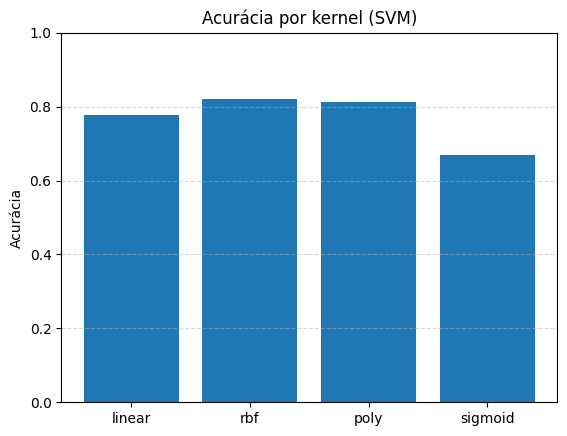

In [10]:
labels = [k for k, _ in resultados]
accs = [acc for _, acc in resultados]

plt.bar(labels, accs)
plt.title("Acurácia por kernel (SVM)")
plt.ylabel("Acurácia")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


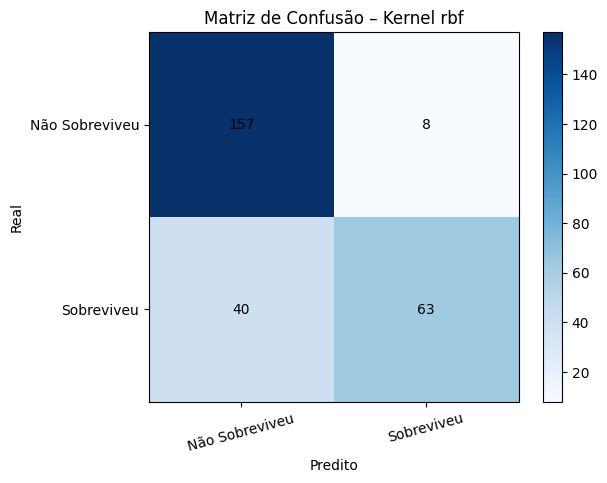

In [11]:
plt.imshow(cm, cmap="Blues", interpolation="nearest")
plt.title(f"Matriz de Confusão – Kernel {melhor_kernel}")
plt.colorbar()

classes = ["Não Sobreviveu", "Sobreviveu"]
ticks = np.arange(len(classes))

plt.xticks(ticks, classes, rotation=15)
plt.yticks(ticks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()
